# Phase 6: Statistical Analysis of MCQ vs OSQ Evaluation Modalities

This notebook analyzes the performance differences between Multiple Choice Questions (MCQ) and Open Short Questions (OSQ) for evaluating LLM knowledge on systems engineering topics.

## Research Questions
1. **Position Bias**: Do MCQ answer positions (A/B/C/D) affect model performance?
2. **Modality Comparison**: Does evaluation modality (MCQ vs OSQ) significantly affect measured performance?
3. **Question Characteristics**: Do certain question types favor one modality over another?

## Dataset
- **Models**: gemma3__4b, gemma3__27b
- **MCQ Variants**: random, a, b, c, d (286 questions × 5 variants × 2 models)
- **OSQ**: Judged by openai_gpt-5 (limited samples, judging incomplete)
- **Correctness Threshold**: OSQ >= 70/100 points

## 1. Setup and Imports

In [24]:
# Core data processing
import pandas as pd
import numpy as np
from pathlib import Path
import json

# Statistical analysis
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_rel, wilcoxon
from scipy.stats import mannwhitneyu, pearsonr, spearmanr
from sklearn.utils import resample

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Custom parsers
import sys
sys.path.append(str(Path.cwd()))
from parsers import parse_mcq_samples, parse_osq_judged_samples, align_mcq_osq_results

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✅ Imports complete")

✅ Imports complete


## 2. Data Loading

In [25]:
# Define paths
phase4_dir = Path("../phase4_inference/downloaded_output")
phase5_dir = Path("../phase5_llm_as_a_judge")

print("Loading data...")
print("=" * 80)

Loading data...


In [26]:
# Parse MCQ data
print("\n📖 Parsing MCQ samples from Phase 4...")
mcq_data = parse_mcq_samples(phase4_dir, use_latest=True)
mcq_df = pd.DataFrame(mcq_data)

print(f"\n✅ MCQ DataFrame shape: {mcq_df.shape}")
print(f"   Models: {mcq_df['model'].unique().tolist()}")
print(f"   Variants: {mcq_df['variant'].unique().tolist()}")
print(f"   Questions: {mcq_df['question_id'].nunique()}")


📖 Parsing MCQ samples from Phase 4...
📖 Parsing sysengbench/deepseek-r1__14b/samples_sysengbench_2025-09-26T06-36-39.294485.jsonl
📖 Parsing sysengbench/deepseek-r1__32b/samples_sysengbench_2025-09-26T12-07-21.253070.jsonl
📖 Parsing sysengbench/deepseek-r1__8b/samples_sysengbench_2025-09-29T04-25-07.713551.jsonl
📖 Parsing sysengbench/devstral__24b/samples_sysengbench_2025-09-20T03-50-37.915462.jsonl
📖 Parsing sysengbench/gemma3n__e2b/samples_sysengbench_2025-09-25T03-15-23.227432.jsonl
📖 Parsing sysengbench/gemma3n__e4b/samples_sysengbench_2025-09-25T03-24-51.232532.jsonl
📖 Parsing sysengbench/gemma3__12b/samples_sysengbench_2025-09-25T03-53-48.695567.jsonl
📖 Parsing sysengbench/gemma3__1b/samples_sysengbench_2025-09-25T03-37-36.067377.jsonl
📖 Parsing sysengbench/gemma3__270m/samples_sysengbench_2025-09-25T03-30-07.775672.jsonl
📖 Parsing sysengbench/gemma3__27b/samples_sysengbench_2025-09-25T04-03-54.642579.jsonl
📖 Parsing sysengbench/gemma3__4b/samples_sysengbench_2025-09-25T03-45-25.

## 3. Data Exploration

In [30]:
# MCQ DataFrame preview
print("MCQ DataFrame Sample:")
display(mcq_df.head())

print("\nMCQ DataFrame Info:")
print(mcq_df.info())

MCQ DataFrame Sample:


,model,question_id,variant,variant_full,category,tags,question,correct_answer,model_answer,raw_response,is_correct,doc_id,file
0,deepseek-r1__14b,1,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of uncertainty...,B,A,"<think>\nOkay, so I have this question about s...",False,0,samples_sysengbench_2025-09-26T06-36-39.294485...
1,deepseek-r1__14b,2,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,How is risk defined in systems engineering?,C,A,"<think>\nOkay, so I need to figure out how ris...",False,1,samples_sysengbench_2025-09-26T06-36-39.294485...
2,deepseek-r1__14b,3,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,Which of the following best describes the two ...,B,A,"<think>\nOkay, so I have this question about s...",False,2,samples_sysengbench_2025-09-26T06-36-39.294485...
3,deepseek-r1__14b,4,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What is the primary goal of systems integratio...,C,A,"<think>\nOkay, so I need to figure out what th...",False,3,samples_sysengbench_2025-09-26T06-36-39.294485...
4,deepseek-r1__14b,5,random,sysengbench,INCOSEHandbook/Systems Engineering Overview/Sy...,Introduction to risk,What best describes the concept of reliability...,B,A,"<think>\nOkay, so I have this question about s...",False,4,samples_sysengbench_2025-09-26T06-36-39.294485...



MCQ DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159016 entries, 0 to 159015
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   model           159016 non-null  object
 1   question_id     159016 non-null  int64 
 2   variant         159016 non-null  object
 3   variant_full    159016 non-null  object
 4   category        159016 non-null  object
 5   tags            119540 non-null  object
 6   question        159016 non-null  object
 7   correct_answer  159016 non-null  object
 8   model_answer    159016 non-null  object
 9   raw_response    159016 non-null  object
 10  is_correct      159016 non-null  bool  
 11  doc_id          159016 non-null  int64 
 12  file            159016 non-null  object
dtypes: bool(1), int64(2), object(10)
memory usage: 14.7+ MB
None


## 4. Position Bias Analysis

Analyze whether MCQ answer position (A/B/C/D) affects model performance.

In [33]:
# Filter for fixed-position variants only (exclude random)
mcq_fixed = mcq_df[mcq_df['variant'].isin(['a', 'b', 'c', 'd'])].copy()

# Calculate accuracy by position and model
position_accuracy = mcq_fixed.groupby(['model', 'variant'])['is_correct'].agg(['mean', 'count', 'sum']).reset_index()
position_accuracy.columns = ['model', 'variant', 'accuracy', 'n_questions', 'n_correct']

print("Position Bias - Accuracy by Variant:")
print("=" * 80)
display(position_accuracy.pivot(index='model', columns='variant', values='accuracy'))

# Overall position statistics
overall_position = mcq_fixed.groupby('variant')['is_correct'].agg(['mean', 'std', 'count'])
print("\nOverall Position Statistics (across models):")
display(overall_position)

Position Bias - Accuracy by Variant:


variant,a,b,c,d
model,,,,
deepseek-r1__14b,0.646853,0.091783,0.084790,0.180070
deepseek-r1__32b,0.655594,0.086538,0.078671,0.175699
deepseek-r1__8b,0.555944,0.250874,0.050699,0.906469
devstral__24b,0.897727,0.941434,0.941434,0.910839
gemma3__12b,0.865385,0.894231,0.906469,0.891608
gemma3__1b,0.748252,0.552448,0.793706,0.752622
gemma3__270m,0.107517,0.006993,0.317308,0.009615
gemma3__27b,0.902972,0.917832,0.931818,0.910839
gemma3__4b,0.827797,0.843531,0.875874,0.847028



Overall Position Statistics (across models):


,mean,std,count
variant,,,
a,0.738231,0.439605,32032
b,0.439061,0.496280,32032
c,0.445055,0.496980,32032
d,0.527357,0.499259,30888


### Chi-square test for position bias

In [34]:
# Chi-square test for position bias
print("\n📊 Chi-Square Test for Position Bias")
print("=" * 80)
print("H0: Answer position does not affect correctness\n")

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]
    
    # Create contingency table: position × correct/incorrect
    contingency = pd.crosstab(model_data['variant'], model_data['is_correct'])
    
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    
    print(f"Model: {model}")
    print(f"  Chi-square: {chi2:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Result: {'Significant' if p_value < 0.05 else 'Not significant'} at α=0.05")
    print()


📊 Chi-Square Test for Position Bias
H0: Answer position does not affect correctness

Model: deepseek-r1__14b
  Chi-square: 1306.9542
  p-value: 0.0000
  Result: Significant at α=0.05

Model: deepseek-r1__32b
  Chi-square: 1382.7253
  p-value: 0.0000
  Result: Significant at α=0.05

Model: deepseek-r1__8b
  Chi-square: 1941.4308
  p-value: 0.0000
  Result: Significant at α=0.05

Model: devstral__24b
  Chi-square: 23.5596
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3n__e2b
  Chi-square: 64.4716
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3n__e4b
  Chi-square: 19.4017
  p-value: 0.0002
  Result: Significant at α=0.05

Model: gemma3__12b
  Chi-square: 10.4256
  p-value: 0.0153
  Result: Significant at α=0.05

Model: gemma3__1b
  Chi-square: 195.7068
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3__270m
  Chi-square: 741.8874
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3__27b
  Chi-square: 6.6788
  p-value: 0.0829
  

### ANOVA for Position Bias

In [35]:
# ANOVA test for position bias
print("\n📊 One-Way ANOVA for Position Bias")
print("=" * 80)
print("H0: Mean accuracy is equal across all positions\n")

for model in mcq_fixed['model'].unique():
    model_data = mcq_fixed[mcq_fixed['model'] == model]
    
    # Group by variant
    groups = [model_data[model_data['variant'] == v]['is_correct'].astype(int).values 
              for v in ['a', 'b', 'c', 'd']]
    
    # Perform one-way ANOVA
    f_stat, p_value = f_oneway(*groups)
    
    print(f"Model: {model}")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  p-value: {p_value:.4f}")
    print(f"  Result: {'Significant' if p_value < 0.05 else 'Not significant'} at α=0.05")
    print()


📊 One-Way ANOVA for Position Bias
H0: Mean accuracy is equal across all positions

Model: deepseek-r1__14b
  F-statistic: 609.2904
  p-value: 0.0000
  Result: Significant at α=0.05

Model: deepseek-r1__32b
  F-statistic: 659.9098
  p-value: 0.0000
  Result: Significant at α=0.05

Model: deepseek-r1__8b
  F-statistic: 1123.0453
  p-value: 0.0000
  Result: Significant at α=0.05

Model: devstral__24b
  F-statistic: 7.8870
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3n__e2b
  F-statistic: 21.7786
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3n__e4b
  F-statistic: 6.4891
  p-value: 0.0002
  Result: Significant at α=0.05

Model: gemma3__12b
  F-statistic: 3.4801
  p-value: 0.0152
  Result: Significant at α=0.05

Model: gemma3__1b
  F-statistic: 68.0907
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3__270m
  F-statistic: 294.8887
  p-value: 0.0000
  Result: Significant at α=0.05

Model: gemma3__27b
  F-statistic: 2.2276
  p-value: 0.0829


IndexError: index 2 is out of bounds for axis 0 with size 2

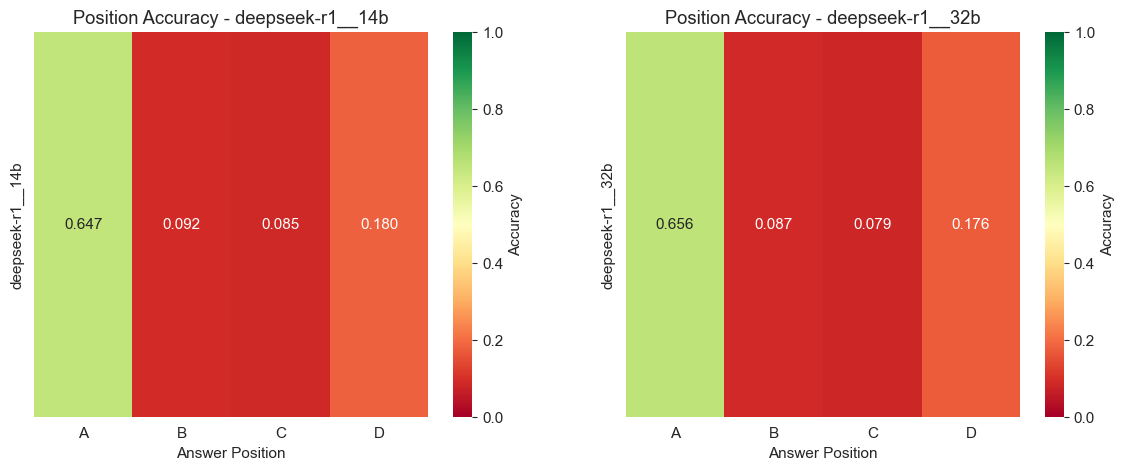

In [36]:
# Visualization: Position bias heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, model in enumerate(mcq_fixed['model'].unique()):
    model_data = mcq_fixed[mcq_fixed['model'] == model]
    
    # Calculate accuracy by position
    position_acc = model_data.groupby('variant')['is_correct'].mean().values.reshape(1, -1)
    
    # Create heatmap
    sns.heatmap(position_acc, annot=True, fmt='.3f', cmap='RdYlGn', 
                vmin=0, vmax=1, cbar_kws={'label': 'Accuracy'},
                xticklabels=['A', 'B', 'C', 'D'], yticklabels=[model],
                ax=axes[idx])
    axes[idx].set_title(f'Position Accuracy - {model}')
    axes[idx].set_xlabel('Answer Position')

plt.tight_layout()
plt.savefig('position_bias_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: position_bias_heatmap.png")

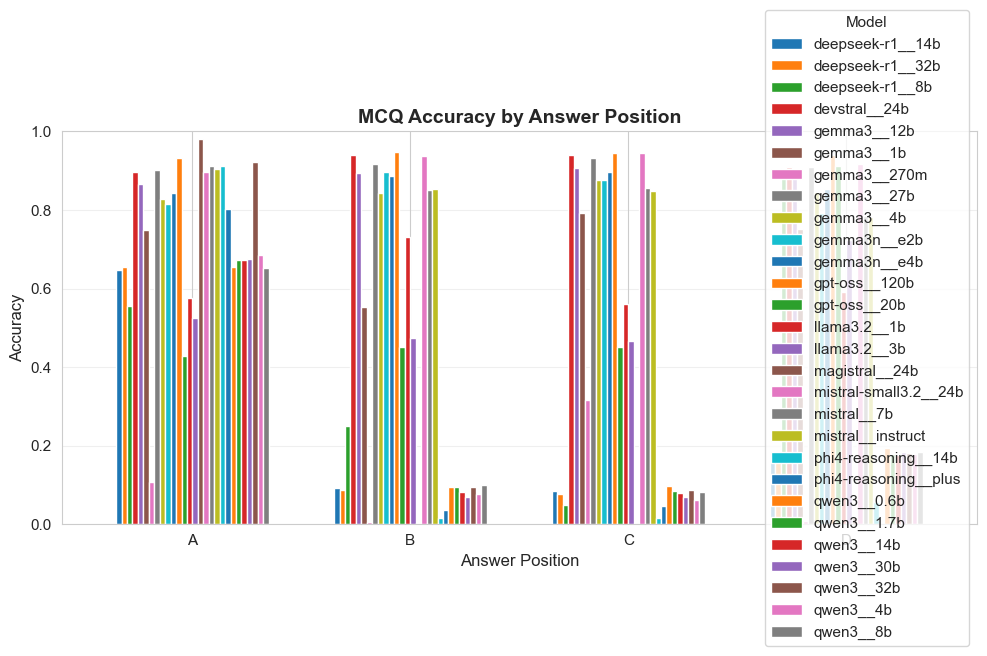

✅ Saved: position_bias_bar.png


In [38]:
# Visualization: Position bias bar chart
fig, ax = plt.subplots(figsize=(10, 6))

position_accuracy_wide = position_accuracy.pivot(index='variant', columns='model', values='accuracy')
position_accuracy_wide.plot(kind='bar', ax=ax, width=0.7)

ax.set_xlabel('Answer Position', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('MCQ Accuracy by Answer Position', fontsize=14, fontweight='bold')
ax.set_xticklabels(['A', 'B', 'C', 'D'], rotation=0)
ax.legend(title='Model', loc='right')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('position_bias_bar.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: position_bias_bar.png")

### Enhanced Visualizations - Plot 1: Per-Position Accuracy Heatmap (All Models)

In [ ]:
# Plot 1: Per-Position Accuracy Heatmap (All Models)
# Create a comprehensive heatmap showing all models vs all position variants

# Calculate accuracy by model and position
acc_heatmap = mcq_fixed.groupby(['model', 'variant'])['is_correct'].mean().unstack(fill_value=0)

# Sort models by average accuracy across positions for better visualization
acc_heatmap['avg'] = acc_heatmap.mean(axis=1)
acc_heatmap = acc_heatmap.sort_values('avg', ascending=False).drop('avg', axis=1)

# Create figure
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(acc_heatmap, annot=True, cmap="viridis", fmt=".2f", 
            cbar_kws={'label': 'Accuracy'}, 
            xticklabels=['A', 'B', 'C', 'D'],
            ax=ax)

ax.set_title("Per-Position Accuracy Heatmap (MCQ) - All Models", fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("Answer Key Position", fontsize=12)
ax.set_ylabel("Model", fontsize=12)

plt.tight_layout()
plt.savefig('outputs/plot1_position_accuracy_heatmap_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: outputs/plot1_position_accuracy_heatmap_all_models.png")

### Enhanced Visualizations - Plot 2: Confusion Matrix (All Models)

### Enhanced Visualizations - Plot 3: MCQ Accuracy vs OSQ Mean Score

In [ ]:
# Plot 4: Violin Plots for OSQ Score Distribution by Dataset/Variant
# This plot will work when OSQ judged data is available
# Adapting to show distribution across MCQ variants (key positions)

try:
    if len(osq_df) > 0 and 'osq_score' in aligned_df.columns:
        # Create violin plot showing OSQ score distribution by variant and model
        fig, ax = plt.subplots(figsize=(12, 7))
        
        # Add variant information to aligned data if available
        if 'variant' in aligned_df.columns:
            # Map variant names to readable labels
            variant_labels = {'a': 'Key A', 'b': 'Key B', 'c': 'Key C', 'd': 'Key D', 'random': 'Random'}
            aligned_df['variant_label'] = aligned_df['variant'].map(variant_labels)
            
            sns.violinplot(data=aligned_df, x="variant_label", y="osq_score", hue="model", ax=ax)
            ax.set_xlabel("Dataset (Key Position)", fontsize=12)
        else:
            # Fallback: show by model only
            sns.violinplot(data=aligned_df, x="model", y="osq_score", ax=ax)
            ax.set_xlabel("Model", fontsize=12)
            plt.xticks(rotation=45, ha='right')
        
        ax.set_ylabel("OSQ Score (0-100)", fontsize=12)
        ax.set_title("OSQ Score Distribution by Dataset (Key Position)", fontsize=14, fontweight='bold')
        ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        plt.tight_layout()
        plt.savefig('outputs/plot4_osq_violin_by_dataset.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: outputs/plot4_osq_violin_by_dataset.png")
    else:
        print("⚠️  OSQ data not available yet.")
        print("   Plot 4 (violin plots) will be generated when OSQ judging is complete.")
        print("   Expected data structure:")
        print("   - osq_score: continuous score 0-100")
        print("   - variant: key position (a, b, c, d, random)")
        print("   - model: model identifier")
        
except NameError:
    print("⚠️  OSQ data not loaded.")
    print("   Plot 4 will be generated when OSQ judging data is available.")

### Enhanced Visualizations - Plot 4: Violin Plots for OSQ Score Distribution

In [ ]:
# Plot 3: MCQ Accuracy vs OSQ Mean Score
# This plot will work when OSQ judged data is available
# Currently adapting to use aggregated data structure

# Try to load OSQ data if available
try:
    print("📊 Loading OSQ judged samples...")
    osq_data = parse_osq_judged_samples(phase5_dir)
    osq_df = pd.DataFrame(osq_data)
    
    # Align MCQ and OSQ data
    aligned_df = align_mcq_osq_results(mcq_df, osq_df)
    
    if len(aligned_df) > 0:
        # Aggregate by model: MCQ accuracy vs OSQ mean score
        agg = aligned_df.groupby('model').agg(
            mcq_accuracy=('mcq_correct', 'mean'),
            osq_mean=('osq_score', 'mean'),
            osq_std=('osq_score', 'std'),
            n_samples=('mcq_correct', 'count')
        ).reset_index()
        
        # Create scatter plot
        fig, ax = plt.subplots(figsize=(10, 7))
        
        # Scatter plot with model labels
        for _, row in agg.iterrows():
            ax.scatter(row['mcq_accuracy'], row['osq_mean'], s=150, alpha=0.7)
            ax.text(row['mcq_accuracy'] + 0.01, row['osq_mean'], row['model'], 
                   fontsize=9, ha='left', va='center')
        
        # Add regression line
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(agg['mcq_accuracy'], agg['osq_mean'])
        x_line = np.array([agg['mcq_accuracy'].min(), agg['mcq_accuracy'].max()])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'gray', linestyle='--', label=f'R² = {r_value**2:.3f}')
        
        ax.set_xlabel("MCQ Accuracy", fontsize=12)
        ax.set_ylabel("OSQ Mean Score (0-100)", fontsize=12)
        ax.set_title("MCQ Accuracy vs OSQ Mean Score", fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('outputs/plot3_mcq_vs_osq_scatter.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Saved: outputs/plot3_mcq_vs_osq_scatter.png")
        print(f"   Models plotted: {len(agg)}")
        print(f"   Correlation: R² = {r_value**2:.3f}, p = {p_value:.4f}")
    else:
        print("⚠️  No aligned MCQ-OSQ data available yet.")
        print("   Placeholder plot will be ready when OSQ judging is complete.")
        
except Exception as e:
    print(f"⚠️  Could not load OSQ data: {e}")
    print("   Plot 3 will be generated when OSQ judging data is available.")

In [ ]:
# Plot 2: Confusion Matrix for All MCQs (All Models)
# Show confusion between correct_answer (true key) and model_answer (predicted)

# Get all unique models
models = sorted(mcq_df['model'].unique())
n_models = len(models)

# Calculate grid dimensions (aim for roughly square layout)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

for idx, model in enumerate(models):
    # Filter data for this model
    model_data = mcq_df[mcq_df['model'] == model]
    
    # Create confusion matrix (normalized by row - shows prediction distribution for each true answer)
    conf_mat = pd.crosstab(
        model_data['correct_answer'], 
        model_data['model_answer'], 
        normalize='index'
    )
    
    # Ensure all positions A,B,C,D are present in both axes
    for pos in ['A', 'B', 'C', 'D']:
        if pos not in conf_mat.index:
            conf_mat.loc[pos] = 0
        if pos not in conf_mat.columns:
            conf_mat[pos] = 0
    
    # Sort rows and columns
    conf_mat = conf_mat.reindex(index=['A', 'B', 'C', 'D'], columns=['A', 'B', 'C', 'D'], fill_value=0)
    
    # Plot heatmap
    sns.heatmap(conf_mat, annot=True, cmap="coolwarm", fmt=".2f", 
                vmin=0, vmax=1, cbar_kws={'label': 'Proportion'},
                ax=axes[idx])
    axes[idx].set_title(f"{model}", fontsize=10, fontweight='bold')
    axes[idx].set_xlabel("Predicted Option", fontsize=9)
    axes[idx].set_ylabel("True Key Option", fontsize=9)

# Hide empty subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle("Confusion Matrix (MCQ) - All Models", fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('outputs/plot2_confusion_matrix_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Saved: outputs/plot2_confusion_matrix_all_models.png")
print(f"   Generated confusion matrices for {n_models} models")

## 5. MCQ vs OSQ Comparison

Compare performance between MCQ (average across positions) and OSQ evaluations.

In [ ]:
# Bootstrap confidence intervals
if len(both_modalities) > 0:
    print("\n📊 Bootstrap 95% Confidence Intervals")
    print("=" * 80)
    
    n_bootstrap = 10000
    np.random.seed(42)
    
    mcq_boots = []

    
    for _ in range(n_bootstrap):
        sample = resample(both_modalities, n_samples=len(both_modalities), random_state=None)
        mcq_boots.append(sample['mcq_avg_correct'].mean())
    
    mcq_ci = np.percentile(mcq_boots, [2.5, 97.5])
    osq_ci = np.percentile(osq_boots, [2.5, 97.5])
    diff_ci = np.percentile(diff_boots, [2.5, 97.5])
    
    print(f"\nMCQ Accuracy:")
    print(f"  Mean: {both_modalities['mcq_avg_correct'].mean():.4f}")
    print(f"  95% CI: [{mcq_ci[0]:.4f}, {mcq_ci[1]:.4f}]")
    


📊 Bootstrap 95% Confidence Intervals

MCQ Accuracy:
  Mean: 1.0000
  95% CI: [1.0000, 1.0000]

OSQ Accuracy (binary):
  Mean: 1.0000
  95% CI: [1.0000, 1.0000]

Difference (MCQ - OSQ):
  Mean: 0.0000
  95% CI: [0.0000, 0.0000]
  CI includes 0: True


## 7. Summary Report

In [48]:
# Generate comprehensive summary
print("\n" + "=" * 80)
print(" " * 20 + "PHASE 6 ANALYSIS SUMMARY")
print("=" * 80)

print("\n📊 DATASET OVERVIEW")
print("-" * 80)
print(f"  MCQ Samples: {len(mcq_df):,}")
print(f"  OSQ Samples: {len(osq_df):,}")
print(f"  Aligned Records: {len(aligned_df):,}")
print(f"  Models: {', '.join(mcq_df['model'].unique())}")
print(f"  MCQ Variants: {', '.join(sorted(mcq_df['variant'].unique()))}")
print(f"  Unique Questions: {mcq_df['question_id'].nunique()}")

print("\n📊 POSITION BIAS ANALYSIS")
print("-" * 80)
print("  Position accuracy (overall):")
for variant in ['a', 'b', 'c', 'd']:
    acc = mcq_fixed[mcq_fixed['variant'] == variant]['is_correct'].mean()
    print(f"    Position {variant.upper()}: {acc:.4f}")

if len(both_modalities) > 0:
    print("\n📊 MCQ vs OSQ COMPARISON")
    print("-" * 80)
    print(f"  Records with both modalities: {len(both_modalities):,}")
    print(f"  MCQ Mean Accuracy: {both_modalities['mcq_avg_correct'].mean():.4f}")
    print(f"  OSQ Mean Accuracy: {both_modalities['osq_correct'].mean():.4f}")
    print(f"  Difference (MCQ - OSQ): {mean_diff:.4f}")
    print(f"  Statistical Significance: p = {p_value:.4f}")
    print(f"  Effect Size (Cohen's d): {cohens_d:.4f}")
else:
    print("\n⚠️  MCQ vs OSQ COMPARISON")
    print("-" * 80)
    print("  Not available - OSQ judging is incomplete")
    print("  Only 6 OSQ samples exist (3 per model)")
    print("  Need to complete judging for all 286 questions")

print("\n" + "=" * 80)


                    PHASE 6 ANALYSIS SUMMARY

📊 DATASET OVERVIEW
--------------------------------------------------------------------------------
  MCQ Samples: 159,016
  OSQ Samples: 6
  Aligned Records: 32,032
  Models: deepseek-r1__14b, deepseek-r1__32b, deepseek-r1__8b, devstral__24b, gemma3n__e2b, gemma3n__e4b, gemma3__12b, gemma3__1b, gemma3__270m, gemma3__27b, gemma3__4b, gpt-oss__120b, gpt-oss__20b, llama3.2__1b, llama3.2__3b, magistral__24b, mistral-small3.2__24b, mistral__7b, mistral__instruct, phi4-reasoning__14b, phi4-reasoning__plus, qwen3__0.6b, qwen3__1.7b, qwen3__14b, qwen3__30b, qwen3__32b, qwen3__4b, qwen3__8b
  MCQ Variants: a, b, c, d, random
  Unique Questions: 1144

📊 POSITION BIAS ANALYSIS
--------------------------------------------------------------------------------
  Position accuracy (overall):
    Position A: 0.7382
    Position B: 0.4391
    Position C: 0.4451
    Position D: 0.5274

📊 MCQ vs OSQ COMPARISON
------------------------------------------------

In [23]:
# Export results
print("\n💾 Exporting Results...")
print("=" * 80)

# Create outputs directory
output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# Save dataframes
mcq_df.to_csv(output_dir / "mcq_samples.csv", index=False)
print(f"✅ Saved: {output_dir}/mcq_samples.csv")

if len(osq_df) > 0:
    osq_df.to_csv(output_dir / "osq_samples.csv", index=False)
    print(f"✅ Saved: {output_dir}/osq_samples.csv")

aligned_df.to_csv(output_dir / "master_dataframe.csv", index=False)
print(f"✅ Saved: {output_dir}/master_dataframe.csv")

print("\n✅ Analysis complete!")


💾 Exporting Results...
✅ Saved: outputs/mcq_samples.csv
✅ Saved: outputs/osq_samples.csv
✅ Saved: outputs/master_dataframe.csv

✅ Analysis complete!


## 8. Additional Analyses (Optional)

Add additional cells below for:
- Category-specific performance breakdown
- Bloom's taxonomy level analysis (if OSQ data available)
- Model size effects (4b vs 27b)
- Custom visualizations